## Autoencoder Training and Anomaly Detection

**Project:** Windows Log Intelligence: Anomaly Detection & Incident Reporting  

### What We Do Here
1. Load the pre-engineered feature matrix 
2. Define and train a **Symmetric Autoencoder** (PyTorch) on normal-pattern data  
3. Compute **per-sample reconstruction error (MSE)**  
4. Set a **percentile-based anomaly threshold**  
5. Label anomalies with severity (LOW / MEDIUM / HIGH / CRITICAL)  
6. Visualise results and export anomaly records

### Architecture
```
Encoder:  Input → 128 → 64 → 32 → 16  (bottleneck)
Decoder:  16   → 32 → 64 → 128 → Input

The Autoencoder is a good choice for this project — given the constraints of no labels, mixed features, class imbalance, and need for explainability, it is the only principled choice among all standard anomaly detection methods.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

sns.set_theme(style='darkgrid')
plt.rcParams.update({'figure.dpi': 130})

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

os.makedirs('../models',          exist_ok=True)
os.makedirs('../data/anomalies',  exist_ok=True)
os.makedirs('../reports',         exist_ok=True)

print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')

PyTorch version : 2.9.1+cpu
Device          : cpu


###  Load Configuration

In [9]:
X = np.load('../data/processed/features.npy')
df_meta = pd.read_csv('../data/processed/metadata.csv')

print(f'Feature matrix : {X.shape}')
print(f'Metadata rows  : {len(df_meta)}')
print(f'Feature stats  → min: {X.min():.3f} | mean: {X.mean():.3f} | max: {X.max():.3f}')

Feature matrix : (158184, 79)
Metadata rows  : 158184
Feature stats  → min: -13.760 | mean: 0.000 | max: 47.844


### Train-Val Split

In [10]:
TRAIN_RATIO = 0.80
n_train     = int(len(X) * TRAIN_RATIO)

# Shuffle indices
idx       = np.random.permutation(len(X))
train_idx = idx[:n_train]
val_idx   = idx[n_train:]

X_train, X_val = X[train_idx], X[val_idx]

print(f'Train size : {X_train.shape[0]:,}')
print(f'Val size   : {X_val.shape[0]:,}')

# Build DataLoaders
BATCH_SIZE = 512

def make_loader(arr, shuffle=True):
    t  = torch.FloatTensor(arr)
    ds = TensorDataset(t, t)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0, pin_memory=(DEVICE.type == 'cuda'))

train_loader = make_loader(X_train, shuffle=True)
val_loader   = make_loader(X_val,   shuffle=False)


Train size : 126,547
Val size   : 31,637


### Define Autoencoder Architecture - Anomalie 

In [11]:
class Autoencoder(nn.Module):
    """
    Symmetric Autoencoder for anomaly detection.
    Learns to reconstruct 'normal' Windows Event Log feature vectors.
    Anomalies produce high reconstruction error (MSE).
    """
    def __init__(self, input_dim: int,hidden_dims=(128, 64, 32),encoding_dim=16):
        super().__init__()

        # Encoder
        enc_dims = [input_dim] + list(hidden_dims) + [encoding_dim]
        enc_layers = []
        for i in range(len(enc_dims) - 1):
            enc_layers.append(nn.Linear(enc_dims[i], enc_dims[i+1]))
            if i < len(enc_dims) - 2:
                enc_layers.extend([
                    nn.BatchNorm1d(enc_dims[i+1]),
                    nn.LeakyReLU(0.2),
                    nn.Dropout(0.2)
                ])
        self.encoder = nn.Sequential(*enc_layers)

        # Decoder
        dec_dims = enc_dims[::-1]
        dec_layers = []
        for i in range(len(dec_dims) - 1):
            dec_layers.append(nn.Linear(dec_dims[i], dec_dims[i+1]))
            if i < len(dec_dims) - 2:
                dec_layers.extend([
                    nn.BatchNorm1d(dec_dims[i+1]),
                    nn.LeakyReLU(0.2),
                    nn.Dropout(0.2)
                ])
        dec_layers.append(nn.Tanh())  # scaled data fits in [-1, 1]
        self.decoder = nn.Sequential(*dec_layers)

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)


INPUT_DIM = X.shape[1]
model     = Autoencoder(input_dim=INPUT_DIM).to(DEVICE)

# Print architecture summary
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nInput Dim      : {INPUT_DIM}')
print(f'Total Parameters: {total_params:,}')

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=79, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2

### Training Loop

In [12]:
# Hyperparameters
EPOCHS        = 50
LR            = 1e-3
WEIGHT_DECAY  = 1e-5

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

history       = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
best_state    = None

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    train_loss = 0.0
    for X_batch, _ in train_loader:
        X_batch = X_batch.to(DEVICE)
        recon   = model(X_batch)
        loss    = criterion(recon, X_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_loader.dataset)

    # Validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, _ in val_loader:
            X_batch  = X_batch.to(DEVICE)
            val_loss += criterion(model(X_batch), X_batch).item() * len(X_batch)
    val_loss /= len(val_loader.dataset)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'Train: {train_loss:.6f} | Val: {val_loss:.6f} | '
              f'Best Val: {best_val_loss:.6f}')

model.load_state_dict(best_state)
print(f'\nTraining complete .  Best val loss: {best_val_loss:.6f}')

Epoch   1/50 | Train: 0.665419 | Val: 0.544389 | Best Val: 0.544389
Epoch   5/50 | Train: 0.531350 | Val: 0.472411 | Best Val: 0.472411
Epoch  10/50 | Train: 0.506683 | Val: 0.451924 | Best Val: 0.451924
Epoch  15/50 | Train: 0.492854 | Val: 0.441508 | Best Val: 0.441508
Epoch  20/50 | Train: 0.486099 | Val: 0.432550 | Best Val: 0.432550
Epoch  25/50 | Train: 0.480643 | Val: 0.429523 | Best Val: 0.429523
Epoch  30/50 | Train: 0.478768 | Val: 0.428140 | Best Val: 0.428140
Epoch  35/50 | Train: 0.478145 | Val: 0.427731 | Best Val: 0.427681
Epoch  40/50 | Train: 0.477778 | Val: 0.427750 | Best Val: 0.427272
Epoch  45/50 | Train: 0.477310 | Val: 0.427281 | Best Val: 0.427175
Epoch  50/50 | Train: 0.477337 | Val: 0.427072 | Best Val: 0.427026

Training complete .  Best val loss: 0.427026


### Training History Visualization

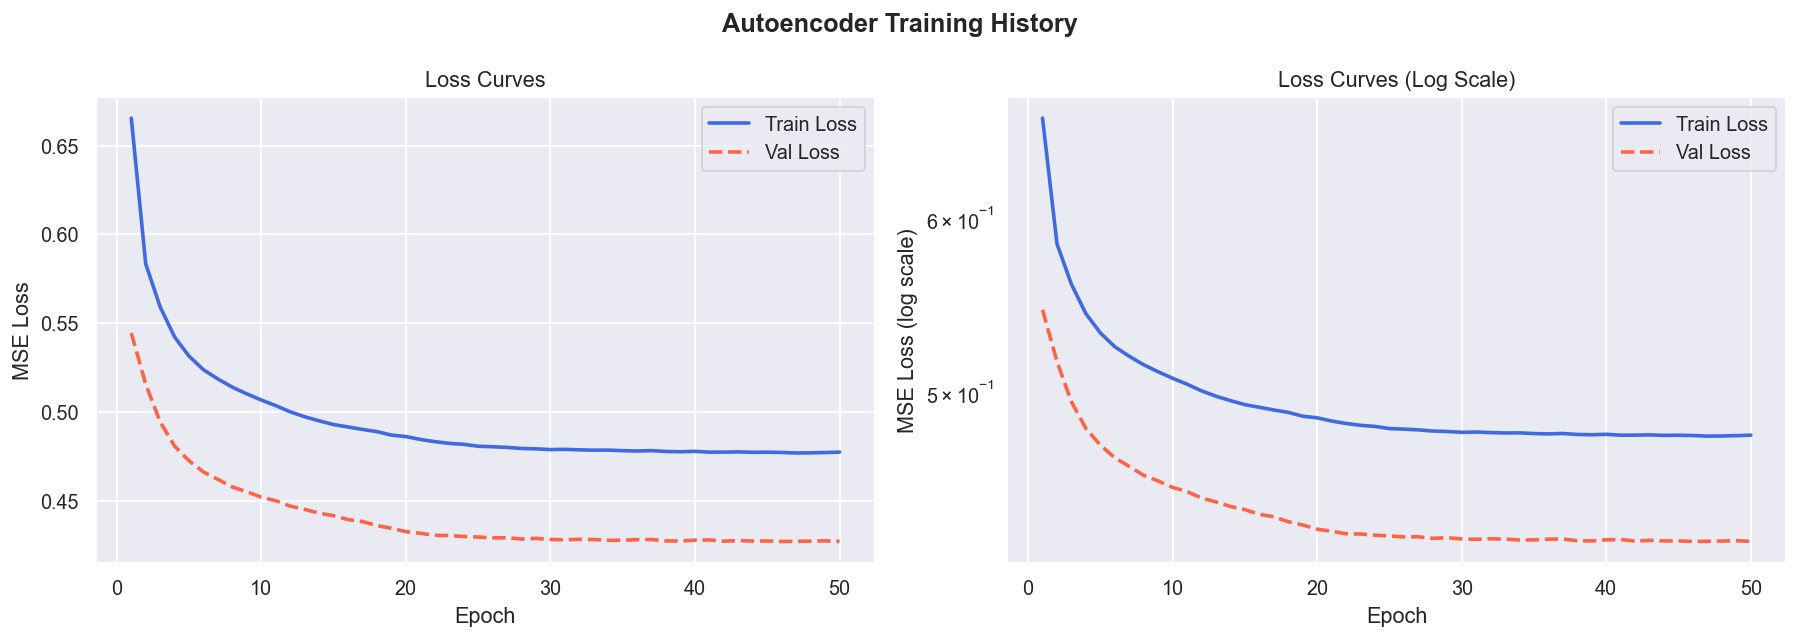

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Autoencoder Training History', fontsize=14, fontweight='bold')

epochs_range = range(1, EPOCHS + 1)

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss',
             color='royalblue', lw=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',
             color='tomato', lw=2, linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()

# Log-scale loss
axes[1].semilogy(epochs_range, history['train_loss'], label='Train Loss',
                 color='royalblue', lw=2)
axes[1].semilogy(epochs_range, history['val_loss'],   label='Val Loss',
                 color='tomato', lw=2, linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss (log scale)')
axes[1].set_title('Loss Curves (Log Scale)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/ae_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

### Compute Reconstruction Errors

In [14]:
model.eval()

def get_reconstruction_errors(X_arr):
    tensor = torch.FloatTensor(X_arr).to(DEVICE)
    with torch.no_grad():
        recon = model(tensor).cpu().numpy()
    # Per-sample MSE
    errors = np.mean((X_arr - recon) ** 2, axis=1)
    return errors

# Compute on ALL samples
all_errors = get_reconstruction_errors(X)

print(f'Reconstruction Error Stats:')
print(f'  Min   : {all_errors.min():.6f}')
print(f'  Mean  : {all_errors.mean():.6f}')
print(f'  Median: {np.median(all_errors):.6f}')
print(f'  95th  : {np.percentile(all_errors, 95):.6f}')
print(f'  99th  : {np.percentile(all_errors, 99):.6f}')
print(f'  Max   : {all_errors.max():.6f}')

Reconstruction Error Stats:
  Min   : 0.006101
  Mean  : 0.433904
  Median: 0.226643
  95th  : 1.997532
  99th  : 3.517714
  Max   : 45.114037


### Anomaly Threshold & Detection


Each flagged anomaly gets a severity based on its normalized anomaly score: LOW / MEDIUM / HIGH / CRITICAL (thresholds at 0.5 / 0.7 / 0.9).

In [15]:
ANOMALY_PERCENTILE = 95.0
threshold = float(np.percentile(all_errors, ANOMALY_PERCENTILE))
print(f'Threshold ({ANOMALY_PERCENTILE}th percentile): {threshold:.6f}')

# Sensitivity analysis
print('\nThreshold Sensitivity:')
print(f'  {'Percentile':<12} {'Threshold':<14} {'#Anomalies':>12} {'Rate':>8}')
print('-' * 52)
for p in [90, 92, 95, 97, 99]:
    t = np.percentile(all_errors, p)
    n = (all_errors > t).sum()
    print(f'  {p:<12} {t:<14.6f} {n:>12,} {n/len(all_errors)*100:>7.2f}%')

Threshold (95.0th percentile): 1.997532

Threshold Sensitivity:
  Percentile   Threshold        #Anomalies     Rate
----------------------------------------------------
  90           0.707201             15,804    9.99%
  92           1.040661             12,655    8.00%
  95           1.997532              7,905    5.00%
  97           2.566421              4,746    3.00%
  99           3.517714              1,582    1.00%


In [16]:
is_anomaly     = all_errors > threshold
anomaly_score  = (all_errors - all_errors.min()) / (all_errors.max() - all_errors.min() + 1e-8)

def severity_label(score):
    if score >= 0.9:   return 'CRITICAL'
    elif score >= 0.7: return 'HIGH'
    elif score >= 0.5: return 'MEDIUM'
    else:              return 'LOW'

severities = np.array([severity_label(s) for s in anomaly_score])

# Attach to metadata
df_meta['reconstruction_error'] = all_errors
df_meta['anomaly_score']        = anomaly_score
df_meta['is_anomaly']           = is_anomaly
df_meta['severity']             = severities

n_anomalies = is_anomaly.sum()
print(f'\nAnomaly Detection Results:')
print(f'  Total records    : {len(df_meta):,}')
print(f'  Anomalies found  : {n_anomalies:,} ({n_anomalies/len(df_meta)*100:.2f}%)')
print(f'  Normal records   : {len(df_meta) - n_anomalies:,}')
print('\nSeverity Breakdown (anomalies only):')
for sev in ['CRITICAL','HIGH','MEDIUM','LOW']:
    cnt = (df_meta[df_meta['is_anomaly']]['severity'] == sev).sum()
    print(f'  {sev:<10}: {cnt:>6,}')


Anomaly Detection Results:
  Total records    : 158,184
  Anomalies found  : 7,905 (5.00%)
  Normal records   : 150,279

Severity Breakdown (anomalies only):
  CRITICAL  :    120
  HIGH      :      0
  MEDIUM    :      1
  LOW       :  7,784


### Reconstruction Error Visualization

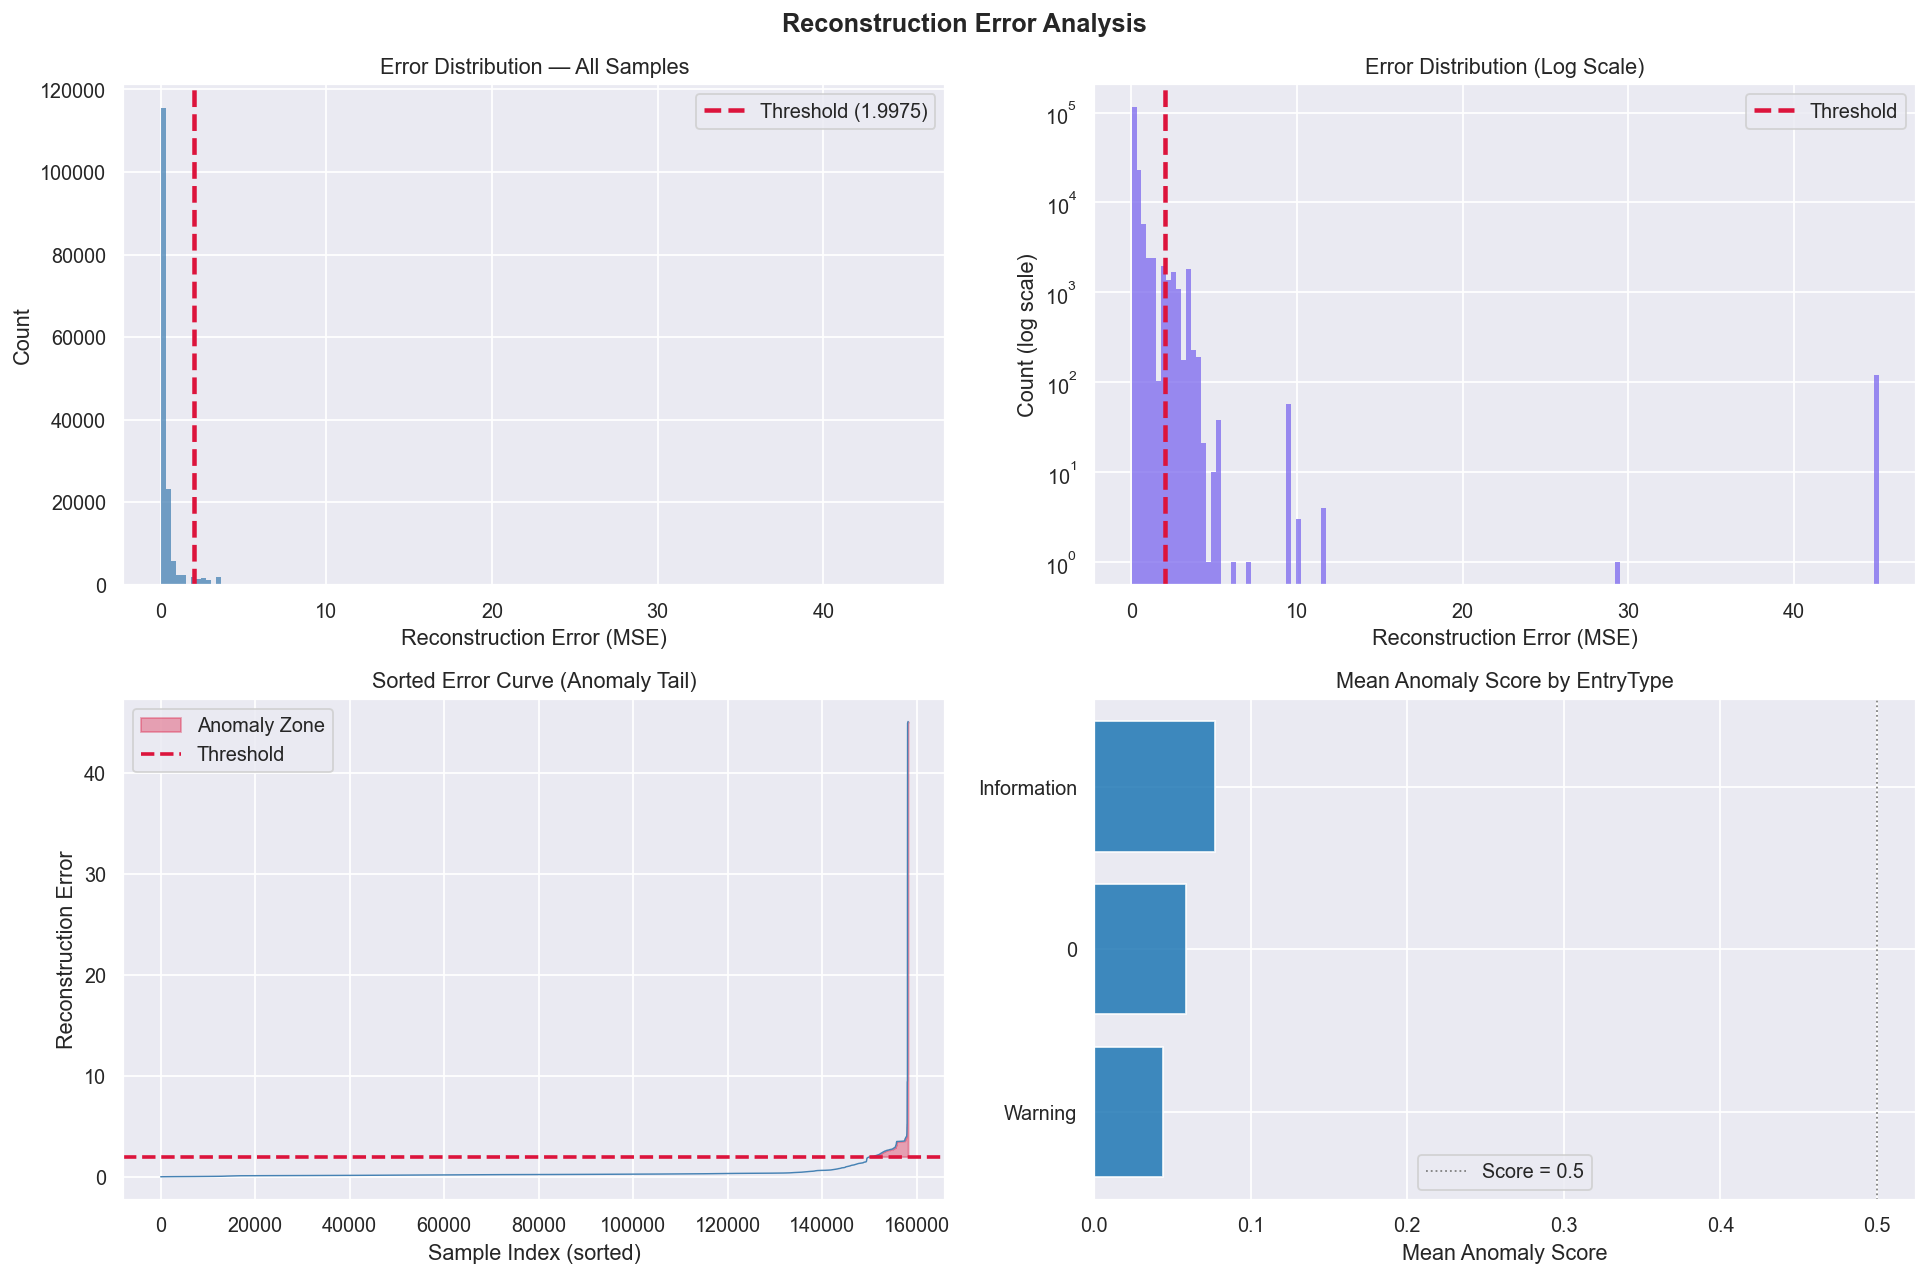

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Reconstruction Error Analysis', fontsize=14, fontweight='bold')

# 1. Error distribution histogram
axes[0,0].hist(all_errors, bins=150, color='steelblue', alpha=0.75, edgecolor='none')
axes[0,0].axvline(threshold, color='crimson', lw=2.5, linestyle='--',
                  label=f'Threshold ({threshold:.4f})')
axes[0,0].set_xlabel('Reconstruction Error (MSE)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Error Distribution — All Samples')
axes[0,0].legend()

# 2. Log-scale histogram
axes[0,1].hist(all_errors, bins=150, color='mediumslateblue', alpha=0.75, edgecolor='none')
axes[0,1].axvline(threshold, color='crimson', lw=2.5, linestyle='--', label='Threshold')
axes[0,1].set_yscale('log')
axes[0,1].set_xlabel('Reconstruction Error (MSE)')
axes[0,1].set_ylabel('Count (log scale)')
axes[0,1].set_title('Error Distribution (Log Scale)')
axes[0,1].legend()

# 3. Sorted error curve
sorted_errors = np.sort(all_errors)
x_range       = np.arange(len(sorted_errors))
anomaly_start = np.searchsorted(sorted_errors, threshold)
axes[1,0].plot(x_range, sorted_errors, color='steelblue', lw=0.8)
axes[1,0].fill_between(x_range[anomaly_start:], sorted_errors[anomaly_start:],
                        threshold, color='crimson', alpha=0.35, label='Anomaly Zone')
axes[1,0].axhline(threshold, color='crimson', lw=2, linestyle='--', label='Threshold')
axes[1,0].set_xlabel('Sample Index (sorted)')
axes[1,0].set_ylabel('Reconstruction Error')
axes[1,0].set_title('Sorted Error Curve (Anomaly Tail)')
axes[1,0].legend()

# 4. Anomaly score per EntryType
anomaly_df = df_meta[df_meta['is_anomaly']]
entry_sev  = anomaly_df.groupby('EntryType')['anomaly_score'].mean().sort_values()
bars = axes[1,1].barh(entry_sev.index, entry_sev.values,
                       color=['#d62728' if v > 0.7 else '#ff7f0e' if v > 0.5 else '#1f77b4'
                              for v in entry_sev.values], alpha=0.85)
axes[1,1].set_xlabel('Mean Anomaly Score')
axes[1,1].set_title('Mean Anomaly Score by EntryType')
axes[1,1].axvline(0.5, color='gray', linestyle=':', lw=1, label='Score = 0.5')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../reports/ae_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

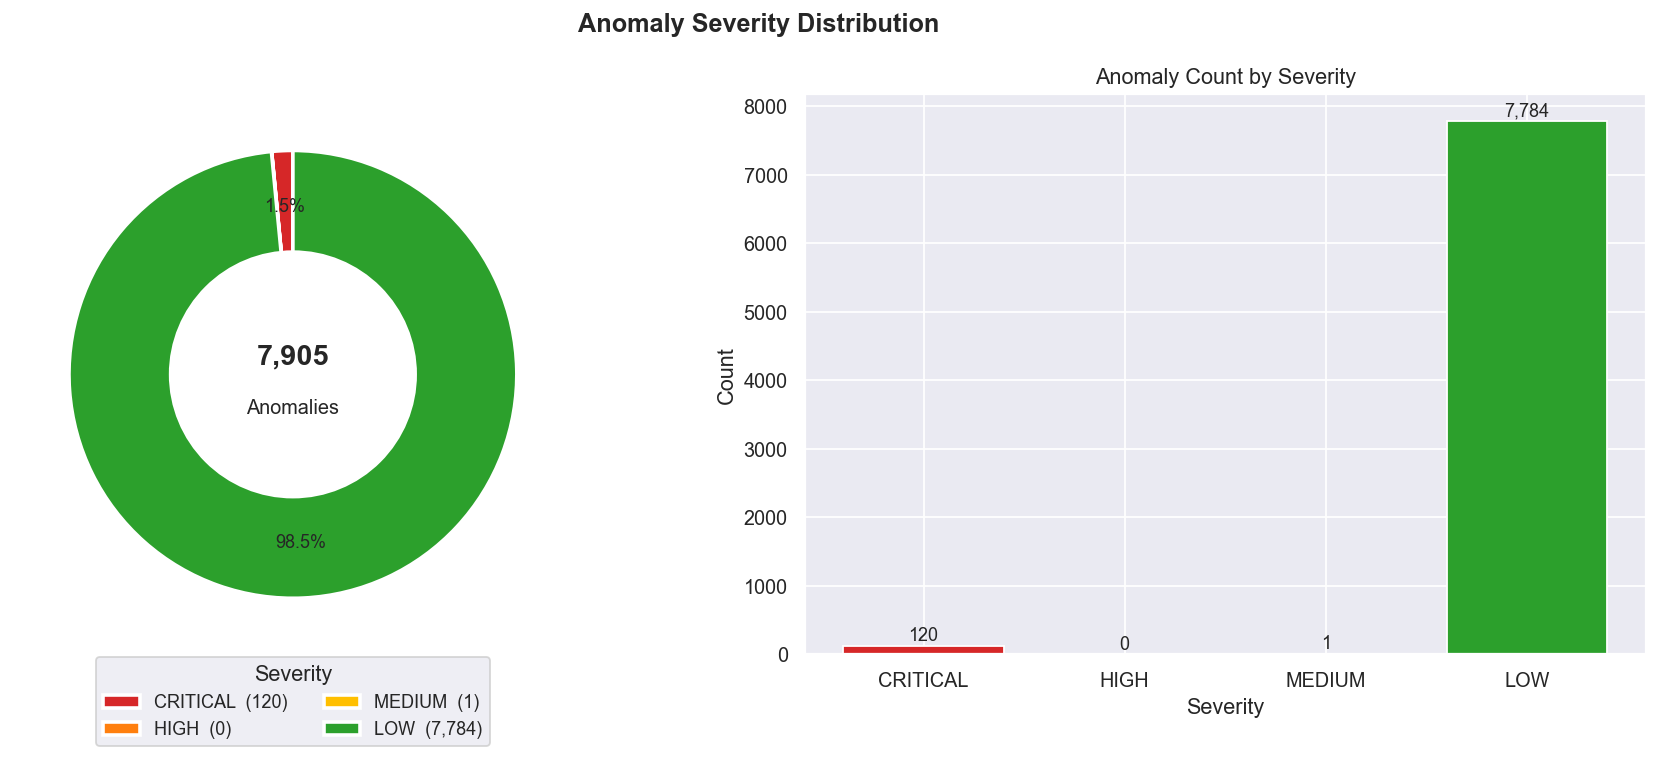

In [18]:
# Severity breakdown donut chart
sev_counts = (anomaly_df['severity'].value_counts().reindex(['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']).fillna(0).astype(int))

colors_sev = ['#d62728', '#ff7f0e', '#ffbf00', '#2ca02c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Anomaly Severity Distribution', fontsize=14, fontweight='bold')

# Donut chart
wedges, texts, autotexts = axes[0].pie(
    sev_counts,
    labels=None,                        
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',   
    colors=colors_sev,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.75
)

for at in autotexts:
    at.set_fontsize(10)

# Donut hole with summary text
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
axes[0].add_patch(centre_circle)
axes[0].text(0, 0.08, f"{sev_counts.sum():,}", ha='center', va='center', fontsize=16, fontweight='bold')
axes[0].text(0, -0.15, "Anomalies", ha='center', va='center', fontsize=11)

# Use a legend instead of overlapping slice labels
axes[0].legend(
    wedges,
    [f"{sev}  ({cnt:,})" for sev, cnt in sev_counts.items()],
    title="Severity",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    fontsize=10
)

# Bar chart (right panel)
bars = axes[1].bar(sev_counts.index, sev_counts.values, color=colors_sev, edgecolor='white')
axes[1].set_title('Anomaly Count by Severity', fontsize=12)
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Severity')

for bar, val in zip(bars, sev_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,f'{val:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/ae_severity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### PCA Latent Space Visualization

Takes the 16-dimensional compressed representation from the bottleneck and projects it to 2D using Principal Component Analysis.


Why: This is the model validation step. Before trusting the anomaly scores you want visual evidence that the model has learned a meaningful separation between normal and anomalous events. If normal and anomaly points are completely mixed in the 2D projection, the bottleneck learned nothing useful. If they form distinct clusters, the model has genuinely learned the structure of normal behavior.


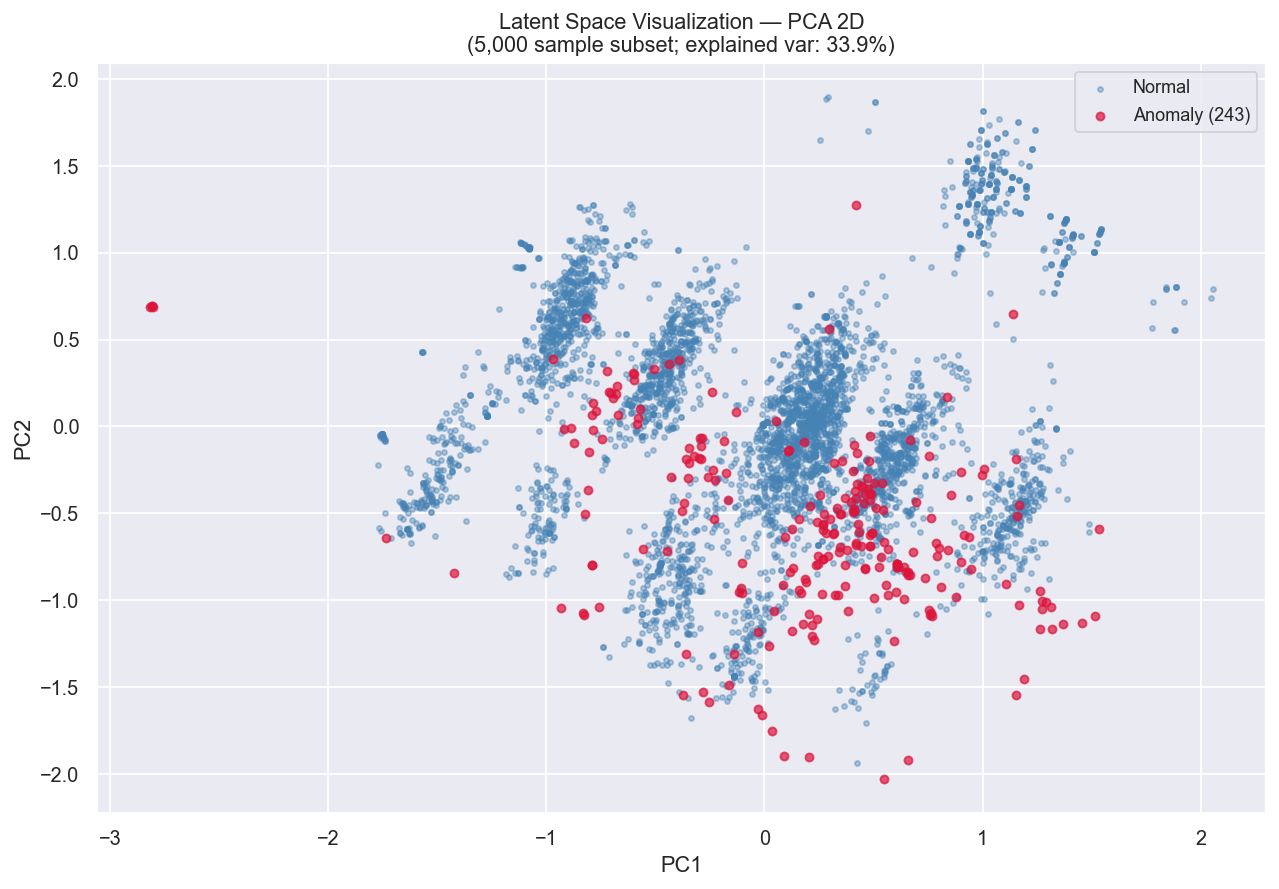

In [19]:
from sklearn.decomposition import PCA

# Get latent representations
model.eval()
sample_idx  = np.random.choice(len(X), size=5000, replace=False)
X_sample    = torch.FloatTensor(X[sample_idx]).to(DEVICE)

with torch.no_grad():
    latent = model.encode(X_sample).cpu().numpy()

labels_sample = is_anomaly[sample_idx]

# PCA to 2D
pca    = PCA(n_components=2, random_state=42)
latent_2d = pca.fit_transform(latent)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(latent_2d[~labels_sample, 0], latent_2d[~labels_sample, 1], s=8, alpha=0.4, color='steelblue', label='Normal')
ax.scatter(latent_2d[labels_sample, 0],  latent_2d[labels_sample, 1], s=20, alpha=0.7, color='crimson', label=f'Anomaly ({labels_sample.sum()})')
ax.set_title(f'Latent Space Visualization — PCA 2D\n'
             f'(5,000 sample subset; explained var: {pca.explained_variance_ratio_.sum()*100:.1f}%)',
             fontsize=12)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../reports/ae_latent_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### Save Model & Results

In [ ]:
# Save model
torch.save(model.state_dict(), '../models/autoencoder/autoencoder_weights.pth')
print('Model saved: ../models/autoencoder/autoencoder_weights.pth')

# Save threshold
joblib.dump({'threshold': threshold, 'percentile': ANOMALY_PERCENTILE},'../models/autoencoder/threshold.pkl')
print('Threshold saved: ../models/autoencoder/threshold.pkl')

# Save errors array
np.save('../data/processed/reconstruction_errors.npy', all_errors)
print('Errors saved: ../data/processed/reconstruction_errors.npy')

# Save anomaly records
anomaly_df_out = df_meta[df_meta['is_anomaly']].copy()
anomaly_df_out.to_csv('../data/anomalies/anomalies.csv', index=False)
print(f'Anomalies saved: ../data/anomalies/anomalies.csv ({len(anomaly_df_out):,} records)')

# Save full labeled metadata
df_meta.to_csv('../data/processed/metadata_labeled.csv', index=False)
print(f'Labeled metadata saved: ../data/processed/metadata_labeled.csv')

print(f'\nAnomaly detection complete!')
print(f'   {n_anomalies:,} anomalies detected ({n_anomalies/len(df_meta)*100:.2f}% rate)')


Model saved: ../models/autoencoder/autoencoder_weights.pth
Threshold saved: ../models/autoencoder/threshold.pkl
Errors saved: ../data/processed/reconstruction_errors.npy
Anomalies saved: ../data/anomalies/anomalies.csv (7,905 records)
Labeled metadata saved: ../data/processed/metadata_labeled.csv

Anomaly detection complete!
   7,905 anomalies detected (5.00% rate)
